# Accompanying Paper code (Example C)
This notebook is the exact same problem as example C but using the exact code blocks present in the paper

In [1]:
# ruff: noqa
import os

os.sys.path.append("../../../..")

In [2]:
from feedback_grape.utils.states import basis, coherent
N_cav = 20
basis_state = basis(n=2)
coherent_state = coherent(n=N_cav, alpha=3)

In [3]:
from feedback_grape.utils.operators import create, destroy
number_operator = create(N_cav) @ destroy(N_cav)

In [4]:
from feedback_grape.utils.tensor import tensor
ground_qubit = basis(n=2)
ground_cavity = basis(n=N_cav)
ground_state = tensor(ground_cavity, ground_qubit)

In [5]:
import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm
from feedback_grape.utils.operators import (
sigmap, sigmam, create, destroy, identity, cosm, sinm
)

In [6]:
def meas_operator(measurement_outcome, params):
    gamma, delta = params
    cav_operator = (
    gamma * create(N_cav) @ destroy(N_cav)
    + delta / 2 * identity(N_cav)
    )
    angle = tensor(cav_operator, identity(2))
    meas_op = jnp.where(
    measurement_outcome == 1,
    cosm(angle),
    sinm(angle),
    )
    return meas_op

In [7]:
def qubit_unitary(alphas):
    alpha_re, alpha_im = alphas
    alpha = alpha_re + 1j * alpha_im
    h_dt = (alpha*sigmap() + alpha.conjugate()*sigmam()) / 2
    return tensor(identity(N_cav), expm(-1j * h_dt))
    
def qubit_cavity_unitary(betas):
    beta_re, beta_im = betas
    beta = beta_re + 1j * beta_im
    a_sigp = tensor(destroy(N_cav), sigmap())
    adag_sigm = tensor(create(N_cav), sigmam())
    h_dt = (beta * a_sigp + beta.conjugate() * adag_sigm) / 2
    return expm(-1j * h_dt)

In [8]:
from feedback_grape.fgrape import Gate

key = jax.random.key(52)
key, subkey = jax.random.split(key)
measure = Gate(
    gate=meas_operator,
    initial_params=jax.random.uniform(
        subkey,
        shape=(2,),
        minval=-jnp.pi,
        maxval= jnp.pi,
    ),
    measurement_flag=True,
)
key, subkey = jax.random.split(key)
qub_unitary = Gate(
    gate=qubit_unitary,
    initial_params=jax.random.uniform(
        subkey,
        shape=(2,),
        minval=-jnp.pi,
        maxval= jnp.pi,
    ),
    measurement_flag=False,
)
key, subkey = jax.random.split(key)
qub_cav = Gate(
    gate=qubit_cavity_unitary,
    initial_params=jax.random.uniform(
        subkey,
        shape=(2,),
        minval=-jnp.pi,
        maxval= jnp.pi,
    ),
    measurement_flag=False,
)

In [9]:
n_average = 1
beta = jnp.log((1 / n_average) + 1)
diags = jnp.exp(-beta * jnp.arange(N_cav))
normalized_diags = diags / jnp.sum(diags, axis=0)
rho_cav0 = jnp.diag(normalized_diags)
rho_qub0 = basis(2, 0) @ basis(2, 0).conj().T
rho0 = tensor(rho_cav0, rho_qub0)

In [10]:
from feedback_grape.utils.states import fock
psi_cav_target = (
    fock(N_cav, 1) + fock(N_cav, 2) + fock(N_cav, 3)
) / jnp.sqrt(3)
psi_qub_target = basis(2, 0)
psi_target = tensor(psi_cav_target, psi_qub_target)
rho_target = psi_target @ psi_target.conj().T

In [11]:
system_params = [measure, qub_unitary, qub_cav]
num_time_steps = 5

In [12]:
from feedback_grape.fgrape import optimize_pulse
result = optimize_pulse(
    init_state=rho0,
    target_state=rho_target,
    system_params=system_params,
    num_time_steps=num_time_steps,
    mode="lookup",
    goal="fidelity",
    max_iter=1000,
    learning_rate=0.02,
    evo_type="density",
    progress=True,
    batch_size=10,
    eval_time_steps=num_time_steps
)

Iteration 10, Reward: 0.187677, Loss: 0.358794, T=3s, eta=301s
Iteration 20, Reward: 0.306628, Loss: 0.426103, T=7s, eta=330s
Iteration 30, Reward: 0.301880, Loss: 0.408004, T=10s, eta=331s
Iteration 40, Reward: 0.384090, Loss: 0.400328, T=13s, eta=325s
Iteration 50, Reward: 0.404552, Loss: 0.349138, T=17s, eta=322s
Iteration 60, Reward: 0.421930, Loss: 0.563125, T=20s, eta=319s
Iteration 70, Reward: 0.397851, Loss: 0.487051, T=24s, eta=317s
Iteration 80, Reward: 0.504879, Loss: 0.535035, T=27s, eta=313s
Iteration 90, Reward: 0.445608, Loss: 0.243501, T=30s, eta=309s
Iteration 100, Reward: 0.455883, Loss: 0.332684, T=34s, eta=304s
Iteration 110, Reward: 0.431556, Loss: 0.312405, T=37s, eta=302s
Iteration 120, Reward: 0.574258, Loss: 0.327411, T=41s, eta=301s
Iteration 130, Reward: 0.563895, Loss: 0.251790, T=44s, eta=297s
Iteration 140, Reward: 0.684634, Loss: 0.223841, T=48s, eta=295s
Iteration 150, Reward: 0.649286, Loss: 0.222590, T=51s, eta=292s
Iteration 160, Reward: 0.752255, Los

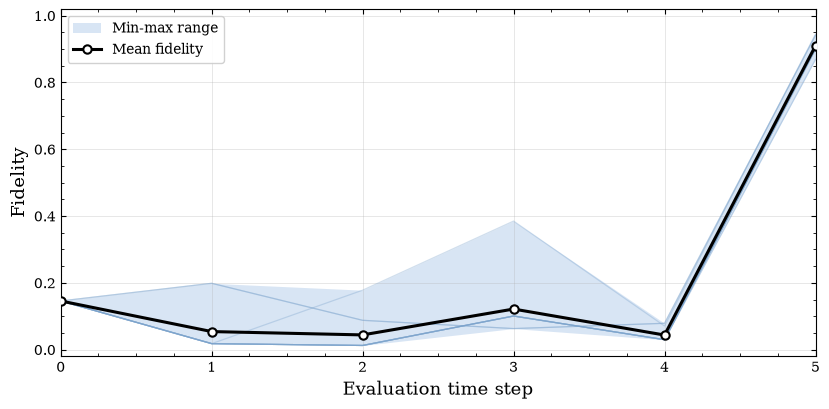

In [13]:
# Fidelity vs. evaluation time step.
# `result.fidelity_each_timestep` is a list of length eval_time_steps + 1
# (index 0 = initial state); each entry holds the fidelity of every
# evaluation trajectory in the batch at that time step.
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.pyplot as plt
n_steps = 5  # only plot the initial state plus the first `n_steps` time steps
fid = jnp.stack(result.fidelity_each_timestep)[: n_steps + 1]  # (n_steps + 1, batch)
t = jnp.arange(fid.shape[0])

fid_mean = fid.mean(axis=1)
fid_min = fid.min(axis=1)
fid_max = fid.max(axis=1)

peak_idx = int(jnp.argmax(fid_mean))
peak_val = float(fid_mean[peak_idx])

with plt.rc_context({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
}):
    fig, ax = plt.subplots(figsize=(10, 4.2))

    # min-max envelope across the evaluation batch
    ax.fill_between(
        t, fid_min, fid_max,
        color="#a9c6e8", alpha=0.45, lw=0, label="Min-max range",
    )
    # individual trajectories, faint, inside the band
    ax.plot(t, fid, color="#7ba3cc", alpha=0.35, lw=0.9)
    # batch-mean fidelity
    ax.plot(
        t, fid_mean,
        color="black", lw=2.2, marker="o", ms=6,
        mfc="white", mec="black", mew=1.5, zorder=5,
        label="Mean fidelity",
    )

    ax.set_xlabel("Evaluation time step", fontsize=13)
    ax.set_ylabel("Fidelity", fontsize=13)
    ax.set_xlim(t[0], t[-1])
    ax.set_ylim(-0.02, 1.02)
    # numbered major ticks plus unnumbered minor ticks on both axes
    ax.set_xticks(t)
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.legend(loc="upper left", framealpha=0.9)
    # leave room on the right for the outside annotation
    fig.tight_layout(rect=(0, 0, 0.84, 1))
    plt.show()

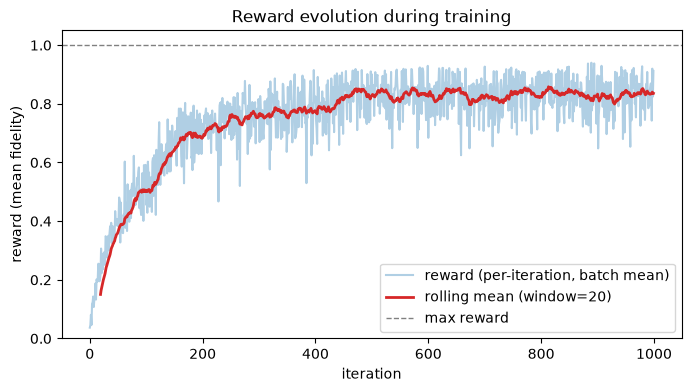

initial reward: 0.0369
final reward:   0.9119
best reward:    0.9401


In [14]:
import matplotlib.pyplot as plt

# `result.reward_history` holds the reward (here the batch-mean fidelity, in
# [0, 1]) at every training iteration, as opposed to the printed loss which
# includes the unbounded log-probability REINFORCE term used for the gradient.
reward_history = result.reward_history
iters = jnp.arange(reward_history.shape[0])

# The reward is estimated over `batch_size` stochastic trajectories, so it is
# noisy; overlay a rolling mean to see the underlying trend.
window = 20
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(iters, reward_history, alpha=0.35, label="reward (per-iteration, batch mean)")
if reward_history.shape[0] >= window:
    smoothed = jnp.convolve(reward_history, jnp.ones(window) / window, mode="valid")
    ax.plot(iters[window - 1:], smoothed, color="C3", lw=2, label=f"rolling mean (window={window})")
ax.axhline(1.0, ls="--", color="gray", lw=1, label="max reward")
ax.set_xlabel("iteration")
ax.set_ylabel("reward (mean fidelity)")
ax.set_ylim(0, 1.05)
ax.set_title("Reward evolution during training")
ax.legend()
plt.show()

print(f"initial reward: {float(reward_history[0]):.4f}")
print(f"final reward:   {float(reward_history[-1]):.4f}")
print(f"best reward:    {float(jnp.nanmax(reward_history)):.4f}")